#  Инициализация весов нейронных сетей. Способы регуляризации нейронных сетей. Продвинутые алгоритмы градиентного спуска.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.init.html
* https://adityassrana.github.io/blog/theory/2020/08/26/Weight-Init.html
* https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/
* https://machinelearningmastery.com/batch-normalization-for-training-of-deep-neural-networks/
* https://pytorch.org/docs/stable/optim.html
* https://seaborn.pydata.org/examples/errorband_lineplots.html

## Задачи для совместного разбора

1\. Инициализируйте веса полносвязного слоя единицами, а смещения - нулями.

2\. Изучите, как работает слой `nn.Dropout` в режиме обучения модели и в режиме использования модели.

3\. Изучите, как работает слой `nn.BatchNorm1d` в режиме обучения модели и в режиме использования модели.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Расширьте класс `torch.nn.Linear`, описав класс `InitializedLinear` и добавив возможность инициализировать веса слоя при помощи функций из пакета `torch.nn.init` (инициализацию bias оставьте по умолчанию). Обратите внимание, что данные функции имеют дополнительные параметры. Данные параметры должны передаваться в момент создания объекта класса `InitializedLinear`.

Пример создания слоя:
```
InitializedLinear(n_features, n_hidden, init_f=nn.init.uniform_, init_args={"a": 0.0, "b": 1.0})
```

- [ ] Проверено на семинаре

In [1]:
import torch
import torch.nn as nn

In [2]:
import torch.nn as nn

class InitializedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True,
                 init_f=None, init_args=None):
        super().__init__(in_features, out_features, bias=bias)

        # если аргументы не переданы
        if init_args is None:
            init_args = {}

        # применяем кастомную инициализацию
        if init_f is not None:
            init_f(self.weight, **init_args)

In [3]:
layer = InitializedLinear(
    10,
    20,
    init_f=nn.init.uniform_,
    init_args={"a": 0.0, "b": 1.0}
)

In [4]:
print(layer.weight)

Parameter containing:
tensor([[7.8508e-02, 3.4866e-01, 3.0064e-01, 1.8793e-01, 8.6059e-01, 1.9129e-01,
         1.2187e-01, 8.2655e-01, 4.7938e-01, 1.9329e-01],
        [2.3709e-01, 2.5863e-01, 9.4761e-01, 3.1138e-01, 5.5019e-01, 2.3818e-01,
         5.9565e-01, 4.7451e-02, 3.2437e-01, 3.2456e-01],
        [8.8274e-01, 3.0354e-01, 2.4501e-01, 7.4748e-01, 1.5525e-01, 7.3835e-01,
         1.6308e-01, 5.3887e-01, 4.1606e-01, 1.5476e-01],
        [2.5580e-01, 2.3053e-01, 2.0816e-02, 7.1228e-01, 5.8834e-01, 5.3348e-01,
         3.6930e-01, 9.0976e-01, 1.9165e-01, 8.2574e-01],
        [1.2633e-01, 8.8873e-02, 1.3942e-01, 4.4842e-02, 1.8419e-01, 2.7487e-01,
         8.1933e-01, 8.9131e-01, 9.5664e-01, 9.3343e-01],
        [3.1255e-01, 2.3386e-01, 9.4158e-01, 8.9160e-01, 4.9237e-01, 5.2942e-01,
         5.5956e-02, 7.3815e-01, 6.7453e-01, 1.9759e-01],
        [6.8645e-01, 4.2775e-01, 2.1731e-02, 8.4342e-01, 3.5942e-02, 1.0563e-01,
         2.2389e-01, 4.9715e-01, 8.6828e-01, 5.8029e-01],
     

<p class="task" id="2"></p>

2\. Решите задачу регрессии несколько раз, изменяя способ инициализации весов. Рассмотрите следующие варианты:
* `nn.init.uniform_`
* `nn.init.normal_`
* `nn.init.constant_`
* `nn.xavier_uniform_` 
* `nn.kaiming_uniform_`
* `nn.xavier_normal_`
* `nn.kaiming_normal_`

Визуализируйте график изменения значений MSE с ходом эпох. Дайте кривым, соответствующие разным способам инициализации, различные цвета и добавьте подписи. Обратите внимание, что от запуска к запуску результаты могут отличаться. Чтобы решить эту проблему, обучайте каждую модель несколько раз и визуализируйте доверительный интервал (можно воспользоваться `seaborn.lineplot`).

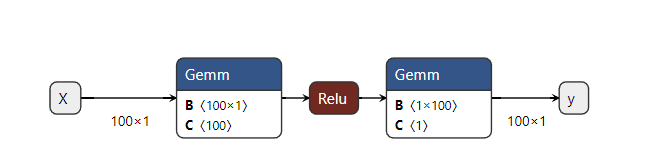

- [ ] Проверено на семинаре

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [29]:
import torch as th
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size()) 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_np = y_test  # для sklearn

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\1937955167.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)


In [30]:
class Net(nn.Module):
    def __init__(self, init_f=None, init_args=None):
        super().__init__()
        in_features = X_train.shape[1]
        self.net = nn.Sequential(
            InitializedLinear(in_features, 32, init_f=init_f, init_args=init_args),
            nn.ReLU(),
            InitializedLinear(32, 1, init_f=init_f, init_args=init_args)
        )

    def forward(self, x):
        return self.net(x)

In [31]:
def train_once(init_f, init_args, epochs=50):
    model = Net(init_f, init_args)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        preds = model(X_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()

        # считаем MSE на тесте
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test).numpy()
            mse = mean_squared_error(y_test_np, test_preds)

        history.append(mse)

    return history

In [32]:
results = []

init_methods = {
    "uniform": (nn.init.uniform_, {"a": -0.1, "b": 0.1}),
    "normal": (nn.init.normal_, {"mean": 0.0, "std": 0.1}),
    "constant": (nn.init.constant_, {"val": 0.1}),
    "xavier_uniform": (nn.init.xavier_uniform_, {}),
    "kaiming_uniform": (nn.init.kaiming_uniform_, {"nonlinearity": "relu"}),
    "xavier_normal": (nn.init.xavier_normal_, {}),
    "kaiming_normal": (nn.init.kaiming_normal_, {"nonlinearity": "relu"}),
}

n_runs = 5
epochs = 50

for name, (init_f, init_args) in init_methods.items():
    for run in range(n_runs):
        mse_history = train_once(init_f, init_args, epochs)

        for epoch, mse in enumerate(mse_history):
            results.append({
                "epoch": epoch,
                "MSE": mse,
                "init": name,
                "run": run
            })

df = pd.DataFrame(results)

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\399017168.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


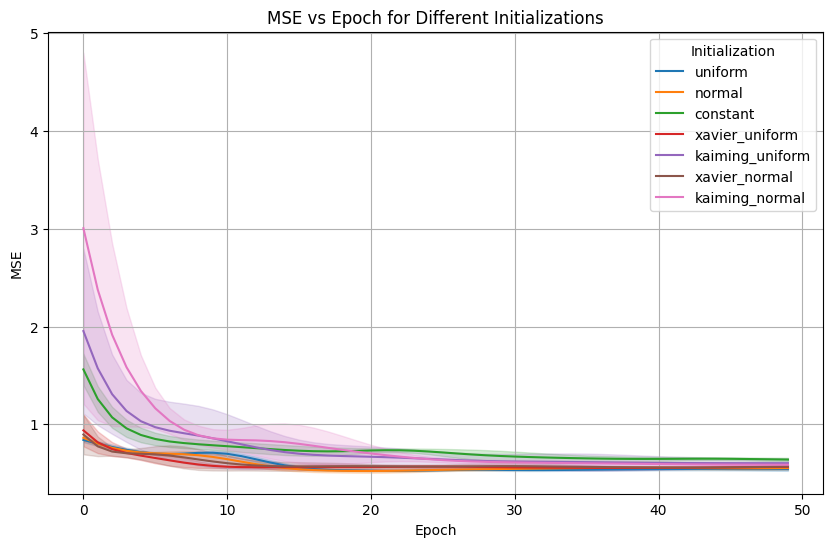

In [33]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="epoch",
    y="MSE",
    hue="init",
    ci="sd"  # доверительный интервал
)

plt.title("MSE vs Epoch for Different Initializations")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(title="Initialization")
plt.grid()

plt.show()

<p class="task" id="3"></p>

3\. Исследуйте, как добавление дропаута влияет на процесс обучения модели. Решите задачу регрессии несколько раз, изменяя значения вероятности дропаута $p$ от 0 до 0.8. В качестве модели рассмотрите нейронную сеть с одним скрытым слоем.

Визуализируйте график изменения значений $R^2$ в зависимости от вероятности дропаута $p$ на обучающей и тестовой выборке. Визуализируйте на отдельном графике зависимости разности между $R^2$ на обучающей выборки и $R^2$ на тестовой выборке.

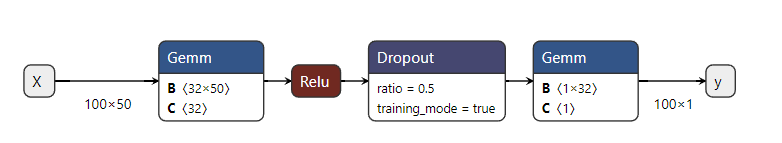

- [ ] Проверено на семинаре

In [34]:
from sklearn.datasets import make_regression
import torch as th

th.manual_seed(42)
X, y, coef = make_regression(
    n_samples=100, 
    n_features=50, 
    n_informative=20, 
    noise=2,
    coef=True,  
    random_state=42,
    
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [35]:
import torch
import torch.nn as nn

class NetDropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        in_features = X_train.shape[1]
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [36]:
import torch.optim as optim
from sklearn.metrics import r2_score

def train_model(p, epochs=50):
    model = NetDropout(p)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    r2_train_hist = []
    r2_test_hist = []

    for epoch in range(epochs):
        # train
        model.train()
        optimizer.zero_grad()

        preds = model(X_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()

        # eval
        model.eval()
        with torch.no_grad():
            train_preds = model(X_train).numpy()
            test_preds = model(X_test).numpy()

        r2_train = r2_score(y_train.numpy(), train_preds)
        r2_test = r2_score(y_test_np, test_preds)

        r2_train_hist.append(r2_train)
        r2_test_hist.append(r2_test)

    return r2_train_hist, r2_test_hist

In [37]:
import numpy as np
import pandas as pd

dropout_values = np.linspace(0, 0.8, 9)  # 0.0 ... 0.8
n_runs = 5
epochs = 50

results = []

for p in dropout_values:
    for run in range(n_runs):
        r2_train_hist, r2_test_hist = train_model(p, epochs)

        for epoch in range(epochs):
            results.append({
                "p": p,
                "epoch": epoch,
                "r2_train": r2_train_hist[epoch],
                "r2_test": r2_test_hist[epoch],
                "gap": r2_train_hist[epoch] - r2_test_hist[epoch],
                "run": run
            })

df = pd.DataFrame(results)

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\2325296537.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="p", y="r2_train", label="Train R²", ci="sd")
C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\2325296537.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="p", y="r2_test", label="Test R²", ci="sd")


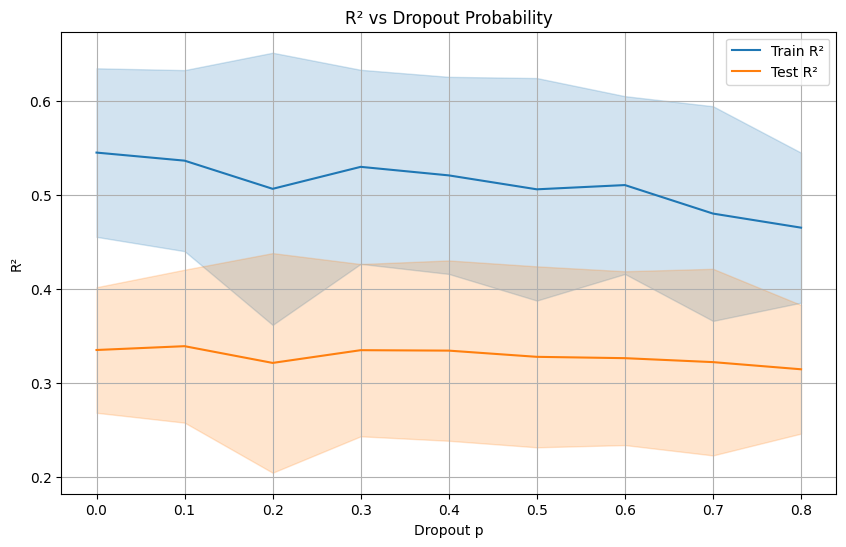

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="p", y="r2_train", label="Train R²", ci="sd")
sns.lineplot(data=df, x="p", y="r2_test", label="Test R²", ci="sd")

plt.title("R² vs Dropout Probability")
plt.xlabel("Dropout p")
plt.ylabel("R²")
plt.grid()

plt.show()

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\3264003810.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="p", y="gap", ci="sd")


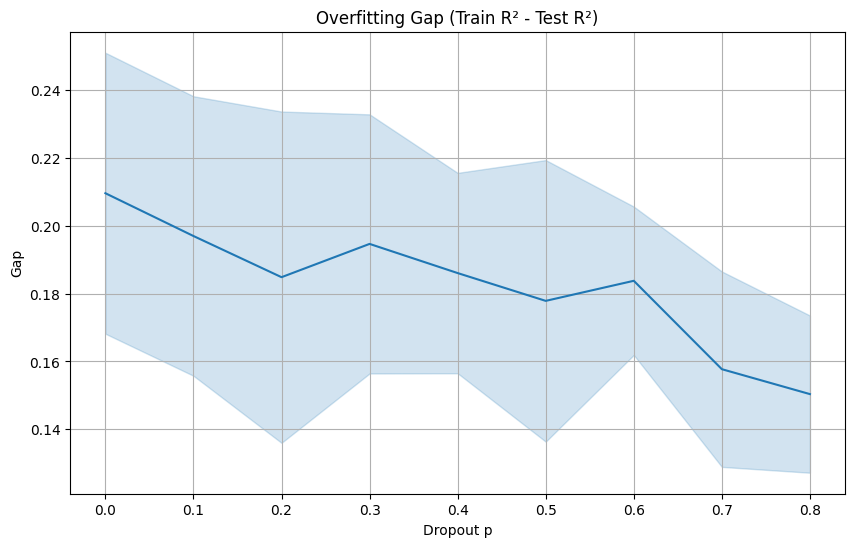

In [39]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="p", y="gap", ci="sd")

plt.title("Overfitting Gap (Train R² - Test R²)")
plt.xlabel("Dropout p")
plt.ylabel("Gap")
plt.grid()

plt.show()

<p class="task" id="4"></p>

4\. Решите задачу регрессии с и без использования пакетной нормализации. Покажите, как меняется результат обучения моделей при различных значениях скорости обучения (0.001, 0.01, 0.1) за одно и то же количество эпох. 

Визуализируйте график изменения значений $R^2$ в зависимости от эпохи при различных значениях скорости обучения с- и без использования пакетной нормализации.

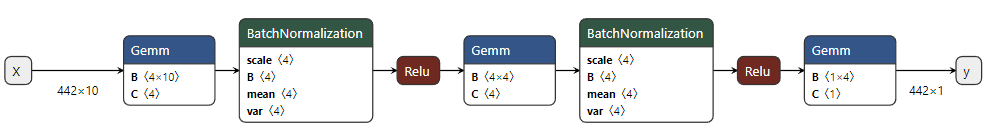

- [ ] Проверено на семинаре

In [40]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
y = (y - y.mean())/y.std()

In [41]:
class NetNoBN(nn.Module):
    def __init__(self):
        super().__init__()
        in_features = X_train.shape[1]
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [42]:
class NetBN(nn.Module):
    def __init__(self):
        super().__init__()
        in_features = X_train.shape[1]
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [43]:
import torch.optim as optim
from sklearn.metrics import r2_score

def train_model(model_class, lr, epochs=50):
    model = model_class()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    r2_history = []

    for epoch in range(epochs):
        # train
        model.train()
        optimizer.zero_grad()

        preds = model(X_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()

        # eval
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test).numpy()

        r2 = r2_score(y_test_np, test_preds)
        r2_history.append(r2)

    return r2_history

In [44]:
import pandas as pd

learning_rates = [0.001, 0.01, 0.1]
epochs = 50
n_runs = 5

results = []

for lr in learning_rates:
    for run in range(n_runs):

        # без BN
        hist_no_bn = train_model(NetNoBN, lr, epochs)
        for epoch, r2 in enumerate(hist_no_bn):
            results.append({
                "epoch": epoch,
                "r2": r2,
                "lr": lr,
                "model": "No BN",
                "run": run
            })

        # с BN
        hist_bn = train_model(NetBN, lr, epochs)
        for epoch, r2 in enumerate(hist_bn):
            results.append({
                "epoch": epoch,
                "r2": r2,
                "lr": lr,
                "model": "BatchNorm",
                "run": run
            })

df = pd.DataFrame(results)

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\3087660757.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


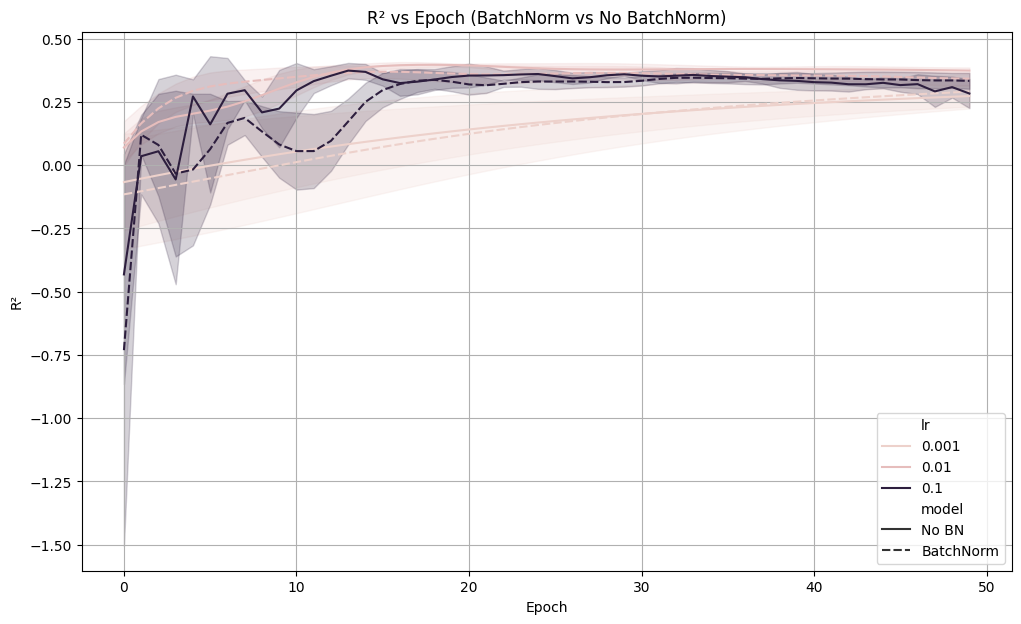

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df,
    x="epoch",
    y="r2",
    hue="lr",
    style="model",
    ci="sd"
)

plt.title("R² vs Epoch (BatchNorm vs No BatchNorm)")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.grid()

plt.show()

<p class="task" id="5"></p>

5\. Решите задачу регрессии c использованием различных алгоритмов градиентного спуска. Покажите, как меняется результат обучения моделей при использовании различных алгоритмов (Adam, Adagrad, RMSProp, SGD) за одно и то же количество эпох с одной и той же скоростью обучения. Используйте модель с архитектурой, аналогичной модели из предыдущей задачи.

Визуализируйте график изменения значений MAPE в зависимости от эпохи при использовании различных алгоритмов градиентного спуска.

- [ ] Проверено на семинаре

In [46]:
def load_boston():
    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    return data, target

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\3520487584.py:6: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [47]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

import torch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_np = y_test

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\2203601756.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)


In [48]:
def mape(y_true, y_pred):
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.detach().cpu().numpy()
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

In [49]:
import torch.optim as optim

def train_model(optimizer_name, lr=0.01, epochs=50):
    model = Net()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "Adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)

    criterion = nn.MSELoss()
    history = []

    for epoch in range(epochs):
        # train
        model.train()
        optimizer.zero_grad()

        preds = model(X_train)
        loss = criterion(preds, y_train)
        loss.backward()
        optimizer.step()

        # eval
        model.eval()
        with torch.no_grad():
            preds_test = model(X_test).numpy().flatten()

        mape_val = mape(y_test_np, preds_test)
        history.append(mape_val)

    return history

In [50]:
import pandas as pd

optimizers = ["Adam", "Adagrad", "RMSprop", "SGD"]
epochs = 50
n_runs = 5

results = []

for opt in optimizers:
    for run in range(n_runs):
        hist = train_model(opt, lr=0.01, epochs=epochs)

        for epoch, val in enumerate(hist):
            results.append({
                "epoch": epoch,
                "MAPE": val,
                "optimizer": opt,
                "run": run
            })

df = pd.DataFrame(results)

C:\Users\alexm\AppData\Local\Temp\ipykernel_14200\3303548607.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


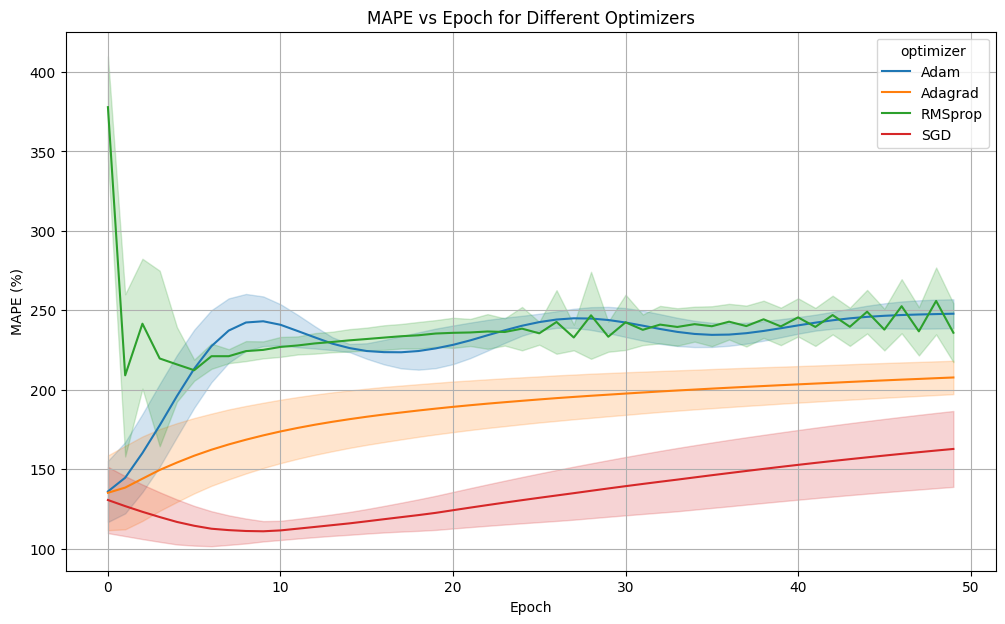

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df,
    x="epoch",
    y="MAPE",
    hue="optimizer",
    ci="sd"
)

plt.title("MAPE vs Epoch for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("MAPE (%)")
plt.grid()

plt.show()